# Lab 7 Exercises - COMP3742 Artificial Intelligence

Student Name: Oliver Wuttke

Student FAN: WUTT0019

File: lab_exercises.ipynb

Date: 25-09-2026

Description: Contains the code and output for the Lab 7 exercises.

In [4]:
# Imports
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit

In [5]:
# Load in sunspot dataset
data = sm.datasets.sunspots.load_pandas().data

# SUNACTIVITY column for forecasting
X = np.arange(len(data)).reshape(-1, 1)
y = data['SUNACTIVITY'].values

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False,
    random_state=42
)

In [7]:
# ARIMA model fitting
arima_model = ARIMA(y_train, order=(5, 1, 5))
arima_model_fit = arima_model.fit()

# Prediction and evaluation
y_pred_arima = arima_model_fit.forecast(steps=len(y_test))
print("ARIMA MSE:", mean_squared_error(y_test, y_pred_arima))

ARIMA MSE: 1548.0405969206975


/Users/oliver/COMP3742 Labs/Lab07_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [12]:
# Train MLP regressor
mlp = MLPRegressor(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=10000
).fit(X_train, y_train)

# Predict and evaluate MLP
y_pred_mlp = mlp.predict(X_test)
print("MLP MSE:", mean_squared_error(y_test, y_pred_mlp))

MLP MSE: 3154.25000269583


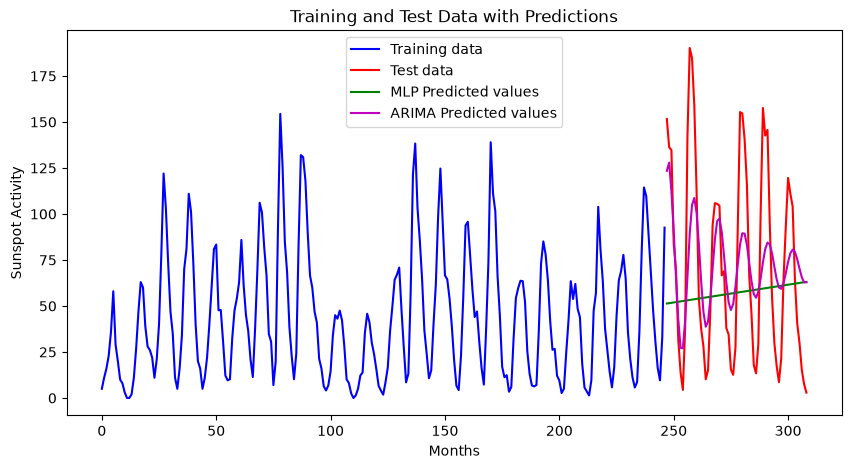

In [13]:
# Plotting
plt.figure(figsize=(10, 5))
plt.plot(X_train[:, -1], y_train, 'b-', label='Training data')
plt.plot(X_test, y_test, 'r-', label='Test data')
plt.plot(X_test, y_pred_mlp, 'g-', label='MLP Predicted values')
plt.plot(X_test, y_pred_arima, 'm-', label='ARIMA Predicted values')
plt.legend()
plt.title('Training and Test Data with Predictions')
plt.xlabel('Months')
plt.ylabel('Sunspot Activity')
plt.show()

In [14]:
# Normalize the data
scaler = StandardScaler()
y_scaled = scaler.fit_transform(y.reshape(-1, 1)).ravel()

In [15]:
# Creating lagged features
def lagged_features(y, lag=5):
    X, y_lagged = [], []
    for i in range(lag, len(y)):
        X.append(y[i - lag:i])
        y_lagged.append(y[i])
    return np.array(X), np.array(y_lagged)

X_lagged, y_lagged = lagged_features(y_scaled)

In [16]:
# Split lagged data
X_train_lagged, X_test_lagged, y_train_lagged, y_test_lagged = train_test_split(
    X_lagged,
    y_lagged,
    test_size=0.2,
    shuffle=False,
    random_state=42
)

In [17]:
# Create MLP model with cross-validation
tscv = TimeSeriesSplit(n_splits=5)
mlp = MLPRegressor(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    max_iter=10000
)

for train_idx, test_idx in tscv.split(X_train_lagged):
    X_train_cv, X_test_cv = X_train_lagged[train_idx], X_train_lagged[test_idx]
    y_train_cv, y_test_cv = y_train_lagged[train_idx], y_train_lagged[test_idx]
    mlp.fit(X_train_cv, y_train_cv)

In [18]:
# Predict and evaluate
y_pred_mlp = mlp.predict(X_test_lagged)
y_pred_mlp = scaler.inverse_transform(y_pred_mlp.reshape(-1, 1)).ravel()
y_test_lagged = scaler.inverse_transform(y_test_lagged.reshape(-1, 1)).ravel()
print("Improved MLP MSE:", mean_squared_error(y_test_lagged, y_pred_mlp))

Improved MLP MSE: 738.572986922235


In [20]:
# Standardize for ARIMA model
arima_model = ARIMA(y_train, order=(5, 1, 5)).fit()

# Predict and evaluate
y_pred_arima = arima_model.forecast(steps=len(y_test))
print("ARIMA MSE:", mean_squared_error(y_test,y_pred_arima))

ARIMA MSE: 1548.0405969206975


/Users/oliver/COMP3742 Labs/Lab07_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [21]:
# Ensure the lengths match
min_length = min(len(y_test), len(y_pred_arima), len(y_pred_mlp))
y_test = y_test[:min_length]
y_pred_arima = y_pred_arima[:min_length]
y_pred_mlp = y_pred_mlp[:min_length]
X_test = X_test[:min_length]

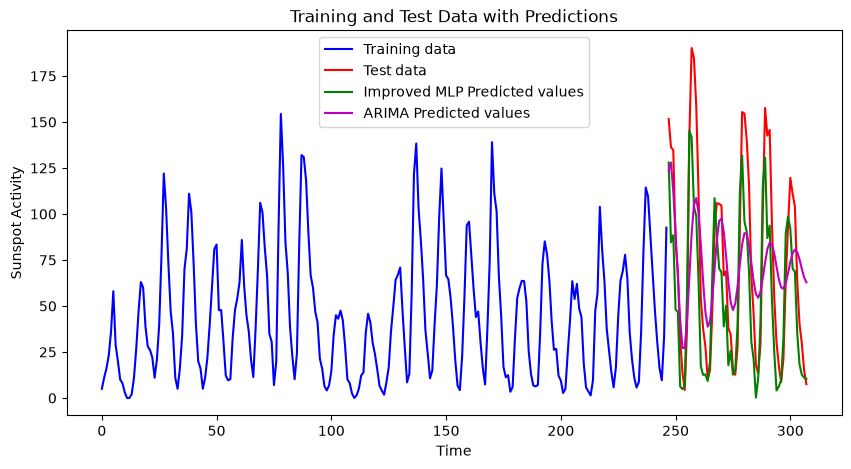

In [22]:
# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(X_train[:, -1], y_train, 'b-', label='Training data')
plt.plot(X_test, y_test, 'r-', label='Test data')
plt.plot(X_test, y_pred_mlp, 'g-', label='Improved MLP Predicted values')
plt.plot(X_test, y_pred_arima, 'm-', label='ARIMA Predicted values')
plt.legend()
plt.title('Training and Test Data with Predictions')
plt.xlabel('Time')
plt.ylabel('Sunspot Activity')
plt.show()